In [48]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import matplotlib.colors as mcolors


In [2]:
import glob
import xarray as xr
PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


KeyboardInterrupt: 

In [3]:
ds = xr.concat(datasets, dim='station')

# Bimonthly - select highest every 2 months
for independence

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import numpy as np
import xarray as xr

time_dim = "valid_time"
station_dim = "station"
var = "residual"

# 1) annual means per station
annual = ds[var].resample({time_dim: "YS"}).mean()

# 2) numeric years since first annual sample, centered for stability
t = xr.DataArray(
    (annual[time_dim] - annual[time_dim].isel({time_dim: 0})) / np.timedelta64(1, "D") / 365.25,
    dims=time_dim,
    coords={time_dim: annual[time_dim]},
)
t = t - t.mean(time_dim)

# 3) mask finite data
y = annual
mask = np.isfinite(y)

# 4) station-wise OLS slope/intercept using xarray algebra
t_masked = t.where(mask)
t_mean = t_masked.mean(time_dim)
y_mean = y.where(mask).mean(time_dim)

cov_ty = ((t - t_mean) * (y - y_mean)).where(mask).sum(time_dim)
var_t = ((t - t_mean) ** 2).where(mask).sum(time_dim)

slope = cov_ty / var_t
intercept = y_mean - slope * t_mean

# 5) evaluate trend on full original time axis
t_full = xr.DataArray(
    (ds[time_dim] - annual[time_dim].isel({time_dim: 0})) / np.timedelta64(1, "D") / 365.25,
    dims=time_dim,
    coords={time_dim: ds[time_dim]},
)
t_full = t_full - t.mean(time_dim)

trend_full = slope * t_full + intercept

# 6) save
ds[f"{var}_annual_mean"] = annual
ds[f"{var}_station_trend_per_year"] = slope
ds[f"{var}_station_intercept"] = intercept
ds[f"{var}_annual_linear_trend"] = trend_full
ds[f"{var}_annual_detrended"] = ds[var] - trend_full

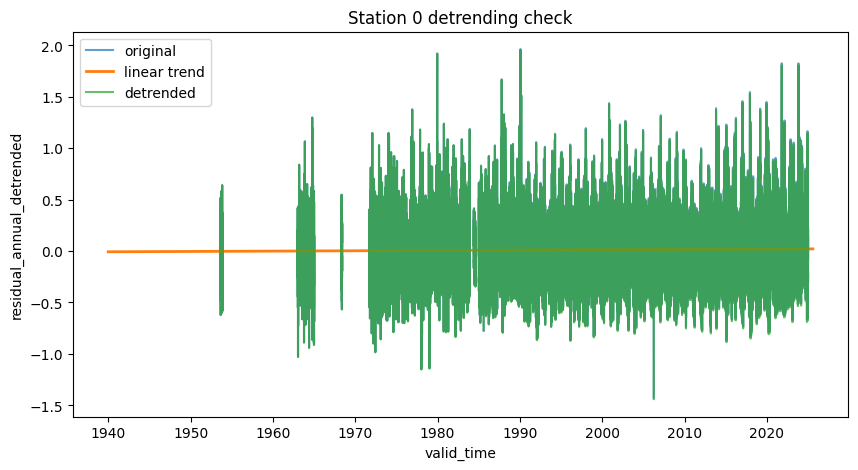

In [6]:
import matplotlib.pyplot as plt
st = ds.isel(station=290)   # or ds.sel(station=1) if labeled
plt.figure(figsize=(10,5))

st["residual"].plot(label='original', alpha=0.7)
st['residual_annual_linear_trend'].plot(label='linear trend', linewidth=2)
st['residual_annual_detrended'].plot(label='detrended', alpha=0.7)

plt.legend()
plt.title('Station 0 detrending check')
plt.show()

In [7]:
select_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_independce/independent_stations.csv")

In [ ]:
import pandas as pd

# 1) Station lookup table from ds
station_lookup = pd.DataFrame({
    "station": ds["station"].values,
    "lat": ds["station_latitude"].values,
    "lon": ds["station_longitude"].values,
})
# 2) Keep only overlapping lat/lon pairs
overlap = station_lookup.merge(
    select_df[["lat", "lon"]].drop_duplicates(),
    on=["lat", "lon"],
    how="inner"
)

# 3) Extract matching station labels
stations_keep = overlap["station"].unique()

# 4) Subset ds only along station dimension
ds_filtered = ds.sel(station=stations_keep)

In [36]:
ds_filtered.to_netcdf("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/selected_filter_stations.nc")

# START HERE

In [3]:
import xarray as xr
ds_filtered = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/selected_filter_stations.nc")

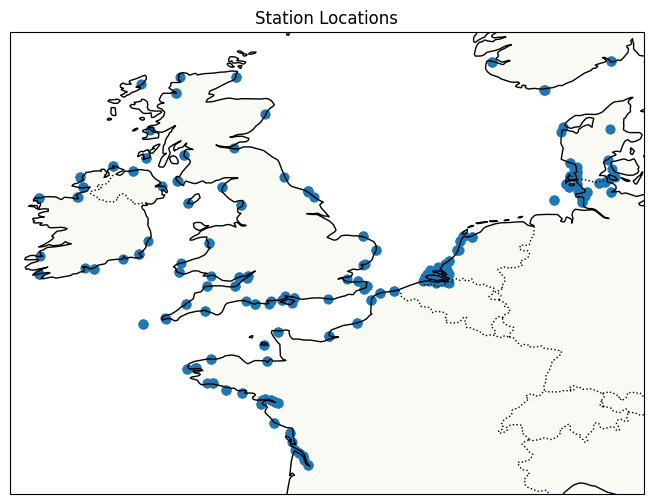

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lats = ds_filtered["station_latitude"].values
lons = ds_filtered["station_longitude"].values

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Scatter stations
ax.scatter(lons, lats, s=40, transform=ccrs.PlateCarree())

# Optional: zoom to region
ax.set_extent([
    lons.min() - 1, lons.max() + 1,
    lats.min() - 1, lats.max() + 1
])

plt.title("Station Locations")
plt.show()

In [27]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st
import pandas as pd
from sklearn.cluster import KMeans

# --- config ---
TARGET_VAR = 'residual_annual_detrended'
N_STATIONS = 295
CSV_OUT = "gev_fit_scores_msl.csv"
N_CLUSTERS = 3

if TARGET_VAR not in ds_filtered.data_vars:
    for v in ds_filtered.data_vars:
        if np.issubdtype(ds_filtered[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

def _meta_for_station(i):
    lat = None
    lon = None
    try:
        lat = float(ds_filtered["station_latitude"].sel(station=i))
        lon = float(ds_filtered["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds_filtered["latitude"])
            lon = float(ds_filtered["longitude"])
        except Exception:
            pass
    return lat, lon

def _time_dim(da):
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

def kuiper_statistic(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / n
    F_mod = cdf_func(x)
    D_plus = np.max(F_emp - F_mod)
    D_minus = np.max(F_mod - (i - 1) / n)
    return D_plus + D_minus

def r2_cdf_fit(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / (n + 1.0)
    F_mod = cdf_func(x)
    ss_res = np.sum((F_emp - F_mod) ** 2)
    ss_tot = np.sum((F_emp - np.mean(F_emp)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

stations = np.array(ds["station"].values)[:N_STATIONS]

results = []

for s in stations:
    try:
        da = ds_filtered[TARGET_VAR].sel(station=s)
    except Exception:
        print(f"Skipping station {s}: not present in ds_filtered.")
        continue

    try:
        tdim = _time_dim(da)
    except Exception as e:
        print(f"Skipping station {s}: could not infer time dimension ({e}).")
        continue

    da = da.where(np.isfinite(da), drop=True)

    if da.size < 10:
        print(f"Skipping station {s}: not enough data after cleaning.")
        continue

    try:
        da_bi = da.resample({tdim: "2M"}).max()
    except Exception as e:
        print(f"Skipping station {s}: resample failed ({e}).")
        continue

    x = da_bi.values.ravel()
    x = x[np.isfinite(x)]

    if x.size < 5:
        print(f"Skipping station {s}: not enough bimonthly maxima ({x.size}).")
        continue

    try:
        gev_params = st.genextreme.fit(x)
        c, loc, scale = gev_params
    except Exception as e:
        print(f"Skipping station {s}: GEV fit failed ({e}).")
        continue

    def gev_cdf(z):
        return st.genextreme.cdf(z, c, loc=loc, scale=scale)

    try:
        ks_stat, ks_p = st.kstest(x, "genextreme", args=gev_params)
        kuiper = kuiper_statistic(x, gev_cdf)
        r2 = r2_cdf_fit(x, gev_cdf)
    except Exception as e:
        print(f"Skipping station {s}: GOF calculation failed ({e}).")
        continue

    lat, lon = _meta_for_station(s)

    results.append({
        "station": int(s),
        "lat": lat,
        "lon": lon,
        "n_blocks": int(x.size),
        "gev_c": c,
        "gev_loc": loc,
        "gev_scale": scale,
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
        "kuiper": kuiper,
        "r2_cdf": r2,
    })

df = pd.DataFrame(results)

if df.empty:
    raise RuntimeError("No stations were successfully fitted. Check your data and config.")

df.to_csv(CSV_OUT, index=False)
print(f"Saved GEV fit parameters and scores to: {CSV_OUT}")

Skipping station 10: not present in ds_filtered.
Skipping station 103: not present in ds_filtered.
Skipping station 109: not present in ds_filtered.
Skipping station 110: not present in ds_filtered.
Skipping station 112: not present in ds_filtered.
Skipping station 113: not present in ds_filtered.
Skipping station 143: not present in ds_filtered.
Skipping station 145: not present in ds_filtered.
Skipping station 157: not present in ds_filtered.
Skipping station 159: not present in ds_filtered.
Skipping station 160: not present in ds_filtered.
Skipping station 163: not present in ds_filtered.
Skipping station 164: not present in ds_filtered.
Skipping station 165: not present in ds_filtered.
Skipping station 173: not present in ds_filtered.
Skipping station 21: not present in ds_filtered.
Skipping station 210: not present in ds_filtered.
Skipping station 254: not present in ds_filtered.
Skipping station 265: not present in ds_filtered.
Skipping station 266: not present in ds_filtered.
Sk

In [5]:
import pandas as pd
df = pd.read_csv("gev_fit_scores_msl.csv")

In [27]:
df.columns

Index(['station', 'lat', 'lon', 'n_blocks', 'gev_c', 'gev_loc', 'gev_scale',
       'ks_stat', 'ks_pvalue', 'kuiper', 'r2_cdf', 'cluster'],
      dtype='object')

In [38]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

features = ['gev_c', 'gev_loc', 'gev_scale',]

X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
from sklearn.cluster import KMeans

k_range = range(2, 10)
inertias = []
labels_list = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    labels_list.append(labels)

In [40]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k, labels in zip(k_range, labels_list):
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

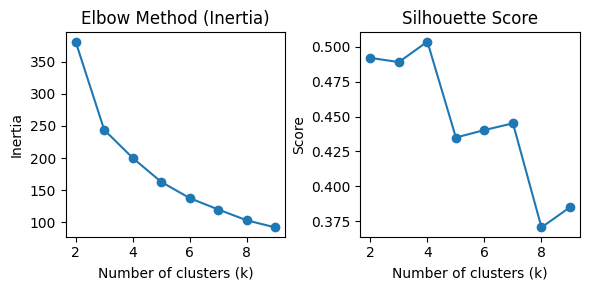

In [78]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# Elbow plot
ax[0].plot(k_range, inertias, marker='o')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Number of clusters (k)')
ax[0].set_ylabel('Inertia')

# Silhouette plot
ax[1].plot(k_range, sil_scores, marker='o')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of clusters (k)')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [42]:
optimal_k = k_range[sil_scores.index(max(sil_scores))]

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [67]:
base_colors = [
      "#8E2DE2",  # purple
     "#1F77B4",  # blue

         "#F2C300",  # yellow

    "#E64B35",  # orange-red (NEW)
 
       "#2CA02C",  # green
]
colors = base_colors[:optimal_k ]
cmap = mcolors.ListedColormap(colors)
bounds = np.arange(optimal_k + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)
cluster_col="cluster"
clusters = np.sort(df[cluster_col].unique())
    # Map cluster labels to 0..K-1 for consistent coloring
cluster_to_index = {c: i for i, c in enumerate(clusters)}
color_index = df[cluster_col].map(cluster_to_index)


In [59]:
import seaborn as sns
sns.pairplot(df, vars=features, hue='cluster', cmap=colors)

TypeError: pairplot() got an unexpected keyword argument 'cmap'

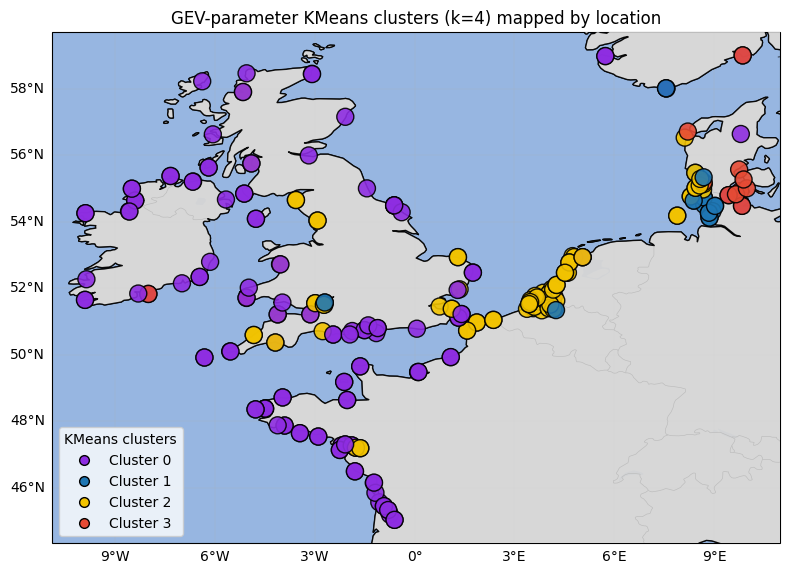

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# dfc must contain: lon, lat, cluster
# best_k is the number of clusters
assert {"lon", "lat", "cluster"}.issubset(df.columns)

# Ensure numeric lon/lat and drop missing
plotdf = df[["lon", "lat", "cluster"]].copy()
plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster"] = pd.to_numeric(plotdf["cluster"], errors="coerce")
plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()

# If best_k not in scope, infer from data
k = int(plotdf["cluster"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)

# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=7, markerfacecolor=cmap(i), markeredgecolor="k",
               label=f"Cluster {i}")
    for i in range(k)
]

# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"].values,
    plotdf["lat"].values,
    c=plotdf["cluster"].values,
    cmap=cmap,
    norm=norm,
    s=150,
    zorder=40,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    edgecolors='black')
ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
ax.legend(handles=handles, title="KMeans clusters", loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

In [71]:
df.to_csv(f"/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/AAFINAL_KMMFIT_4_msl.csv")

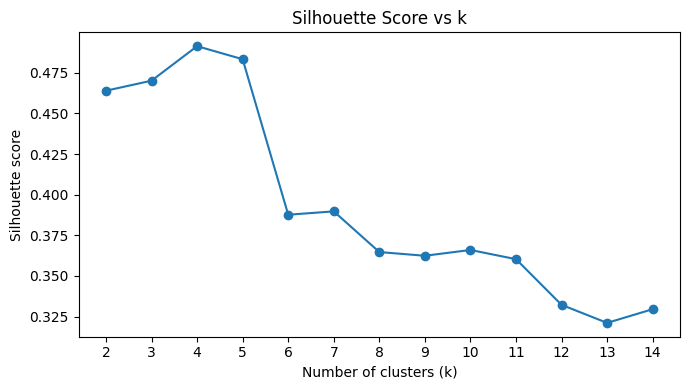

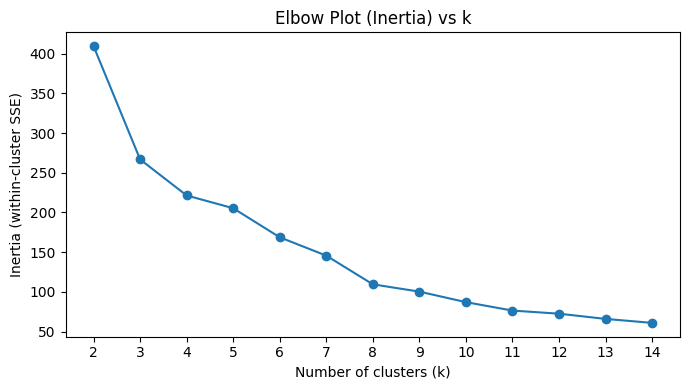

Best k by silhouette: 4
k= 2  silhouette=0.4640  inertia=409.33
k= 3  silhouette=0.4701  inertia=266.74
k= 4  silhouette=0.4914  inertia=221.39
k= 5  silhouette=0.4833  inertia=205.33
k= 6  silhouette=0.3877  inertia=168.73
k= 7  silhouette=0.3897  inertia=145.64
k= 8  silhouette=0.3647  inertia=109.54
k= 9  silhouette=0.3624  inertia=100.34
k=10  silhouette=0.3660  inertia=87.10
k=11  silhouette=0.3604  inertia=76.49
k=12  silhouette=0.3323  inertia=72.56
k=13  silhouette=0.3211  inertia=65.99
k=14  silhouette=0.3296  inertia=60.99


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1) Select GEV parameter features
feat_cols = ["gev_c", "gev_loc", "gev_scale"]
Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")

# 2) Basic cleaning: drop rows with missing params, ensure valid scale
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0]  # scale must be positive

# Align df to Xdf rows
dfc = df.loc[Xdf.index].copy()

# 3) Light stabilization: log-transform scale (often highly skewed)
Xdf = Xdf.copy()
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# 4) Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

k_range = range(2, 15)  # adjust upper bound if you want
sil_scores = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels = km.fit_predict(Xs)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xs, labels))

# -----------------------------
# 1) Silhouette score plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Elbow plot (inertia)
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot (Inertia) vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: choose best k by silhouette
# -----------------------------
best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k_sil)

# Optional: print table for logging
for k, s, iner in zip(k_range, sil_scores, inertias):
    print(f"k={k:2d}  silhouette={s:.4f}  inertia={iner:.2f}")


In [20]:
for seed in range(10):
    km = KMeans(n_clusters=4, random_state=seed, n_init="auto")

Best k by silhouette: 4


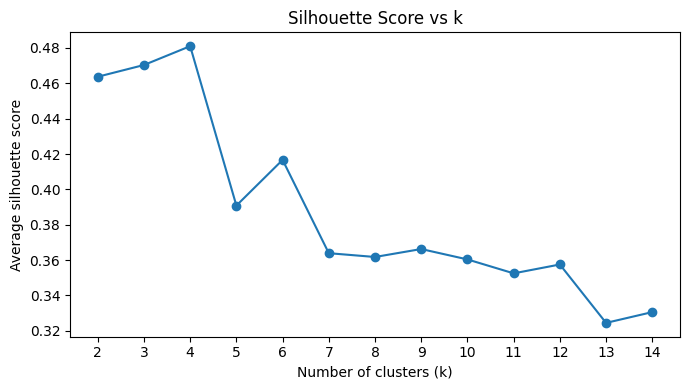

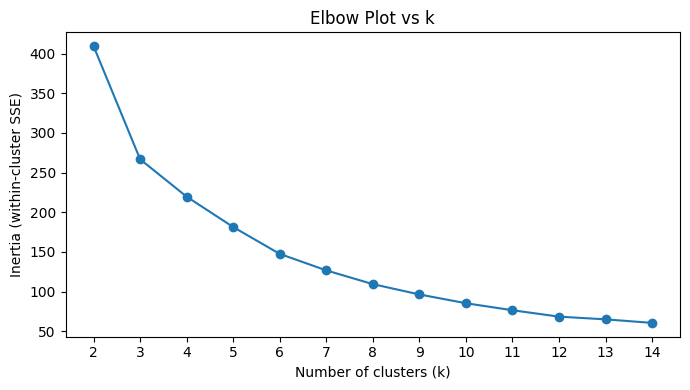

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

# -----------------------------
# 0) Prepare data
# -----------------------------
feat_cols = ["gev_c", "gev_loc", "gev_scale"]
Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0].copy()

dfc = df.loc[Xdf.index].copy()

# log-transform scale
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

# -----------------------------
# 1) Global diagnostics over k
# -----------------------------
k_range = range(2, 15)
sil_scores = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=20)
    labels = km.fit_predict(Xs)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xs, labels))

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette score")
plt.title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot vs k")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.decomposition import PCA
Xp = PCA(n_components=2).fit_transform(Xs)

In [24]:
CSV_OUT = "gev_fit_scores_msl.csv"
# 6) Fit final KMeans
best_k = 6
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = km.fit_predict(Xs)

# 7) Attach cluster labels back to df
dfc["cluster"] = labels + 1

# 8) Save clustered table
CSV_OUT_CLUSTERED = CSV_OUT.replace(".csv", f"_kmeans_gev_k{best_k}.csv")
dfc.to_csv(CSV_OUT_CLUSTERED, index=False)
print(f"Saved clustered GEV parameters to: {CSV_OUT_CLUSTERED}")

# 9) Quick cluster summaries (in original parameter units)
summary = (
    dfc.groupby("cluster")[feat_cols + ["n_blocks", "ks_stat", "kuiper", "r2_cdf"]]
       .agg(["count", "mean", "median", "std"])
)

Saved clustered GEV parameters to: gev_fit_scores_msl_kmeans_gev_k6.csv


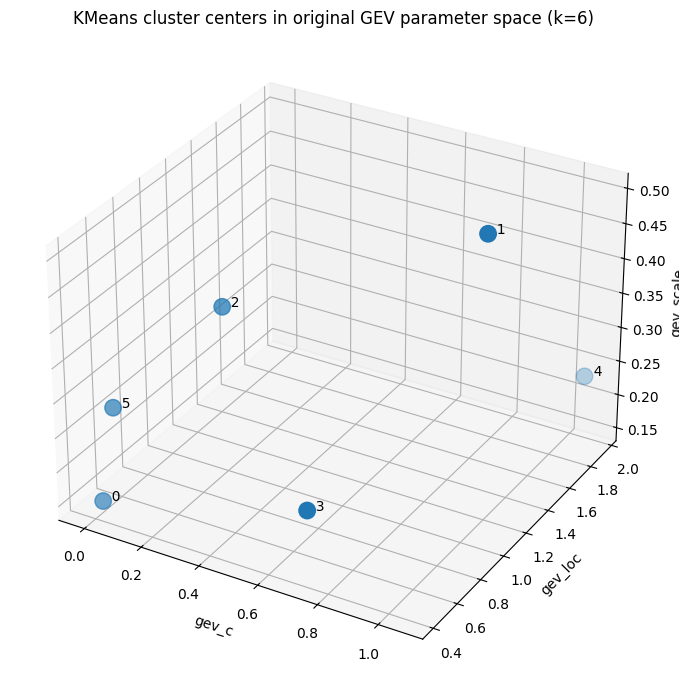

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Feature names (same order as used for fitting)
feat_cols = ["gev_c", "gev_loc", "gev_scale"]

# --------------------------------------------------
# 1. Get cluster centers in standardized space
# --------------------------------------------------
centers_std = km.cluster_centers_  # shape (k, 3)

# --------------------------------------------------
# 2. Invert standardization
# --------------------------------------------------
centers_unscaled = scaler.inverse_transform(centers_std)

# --------------------------------------------------
# 3. Undo log-transform on gev_scale
# --------------------------------------------------
centers_unscaled = centers_unscaled.copy()
centers_unscaled[:, 2] = np.exp(centers_unscaled[:, 2])

# --------------------------------------------------
# 4. Plot in ORIGINAL PARAMETER SPACE
# --------------------------------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    centers_unscaled[:, 0],
    centers_unscaled[:, 1],
    centers_unscaled[:, 2],
    s=140,
    marker="o",
    depthshade=True,
)

# Label each cluster center
for i in range(centers_unscaled.shape[0]):
    ax.text(
        centers_unscaled[i, 0],
        centers_unscaled[i, 1],
        centers_unscaled[i, 2],
        f"  {i}",
        fontsize=10,
    )

ax.set_xlabel("gev_c")
ax.set_ylabel("gev_loc")
ax.set_zlabel("gev_scale")
ax.set_title(f"KMeans cluster centers in original GEV parameter space (k={best_k})")

plt.tight_layout()
plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_95744/3382529528.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)


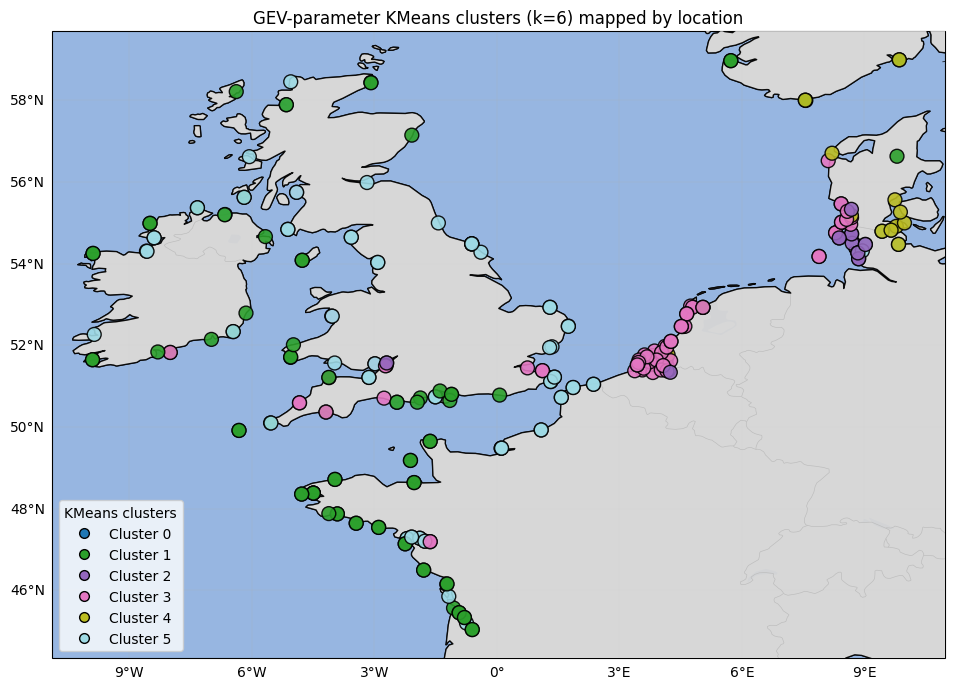

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# dfc must contain: lon, lat, cluster
# best_k is the number of clusters
assert {"lon", "lat", "cluster"}.issubset(dfc.columns)

# Ensure numeric lon/lat and drop missing
plotdf = dfc[["lon", "lat", "cluster"]].copy()
plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster"] = pd.to_numeric(plotdf["cluster"], errors="coerce")
plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()

# If best_k not in scope, infer from data
k = int(plotdf["cluster"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

# Categorical colors for clusters
cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)



# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=7, markerfacecolor=cmap(i), markeredgecolor="k",
               label=f"Cluster {i}")
    for i in range(k)
]

# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"].values,
    plotdf["lat"].values,
    c=plotdf["cluster"].values,
    cmap=cmap,
    norm=norm,
    s=100,
    zorder=40,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    edgecolors='black')
ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
ax.legend(handles=handles, title="KMeans clusters", loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


Saved clustered GEV parameters to: gev_fit_scores_msl_kmeans_gev_k4.csv


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_95744/4155403036.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)


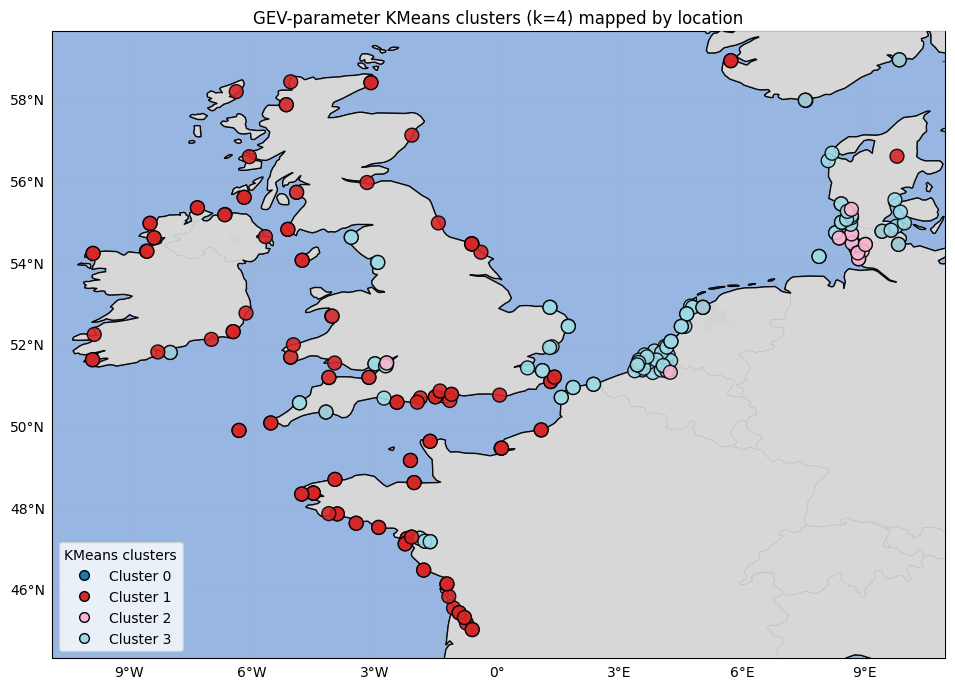

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
best_k = 4
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = km.fit_predict(Xs)

# 7) Attach cluster labels back to df
dfc["cluster"] = labels + 1

# 8) Save clustered table
CSV_OUT_CLUSTERED = CSV_OUT.replace(".csv", f"_kmeans_gev_k{best_k}.csv")
dfc.to_csv(CSV_OUT_CLUSTERED, index=False)
print(f"Saved clustered GEV parameters to: {CSV_OUT_CLUSTERED}")

# 9) Quick cluster summaries (in original parameter units)
summary = (
    dfc.groupby("cluster")[feat_cols + ["n_blocks", "ks_stat", "kuiper", "r2_cdf"]]
       .agg(["count", "mean", "median", "std"])
)
# dfc must contain: lon, lat, cluster
# best_k is the number of clusters
assert {"lon", "lat", "cluster"}.issubset(dfc.columns)

# Ensure numeric lon/lat and drop missing
plotdf = dfc[["lon", "lat", "cluster"]].copy()
plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster"] = pd.to_numeric(plotdf["cluster"], errors="coerce")
plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()

# If best_k not in scope, infer from data
k = int(plotdf["cluster"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

# Categorical colors for clusters
cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)



# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=7, markerfacecolor=cmap(i), markeredgecolor="k",
               label=f"Cluster {i}")
    for i in range(k)
]

# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"].values,
    plotdf["lat"].values,
    c=plotdf["cluster"].values,
    cmap=cmap,
    norm=norm,
    s=100,
    zorder=40,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    edgecolors='black')
ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
ax.legend(handles=handles, title="KMeans clusters", loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


In [44]:
dfc.to_csv(f"/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/AAstation_GEV_{best_k}_msl.csv")

Best k by silhouette: 4
Best k by Calinski-Harabasz: 3
Best k by Davies-Bouldin: 6

Chosen k by combined ranking: 3
     k   inertia  silhouette  calinski_harabasz  davies_bouldin  rank_total  \
0    2  409.3233      0.4637           219.8414          0.8619        20.0   
1    3  266.7255      0.4704           235.3827          0.7310         5.0   
2    4  219.5688      0.4810           207.8365          0.8303        24.0   
3    5  181.2825      0.3908           201.2458          0.8155        28.0   
4    6  147.4206      0.4167           208.6238          0.7229        15.0   
5    7  126.6368      0.3639           208.3571          0.8140        27.0   
6    8  109.3077      0.3618           211.6646          0.7463        21.0   
7    9   96.3029      0.3663           213.5184          0.7457        17.0   
8   10   85.2323      0.3604           217.1100          0.8137        23.0   
9   11   76.4005      0.3525           219.9179          0.8031        21.0   
10  12   68.320

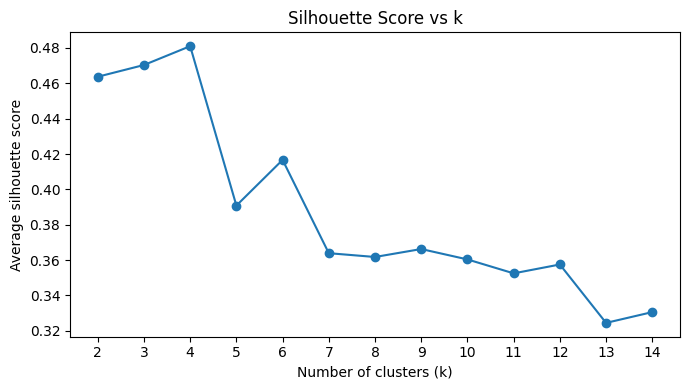

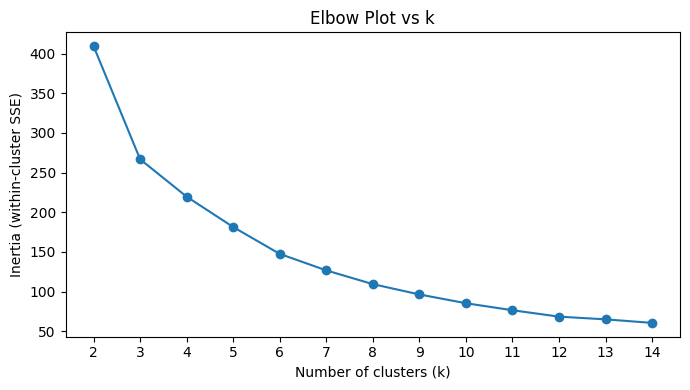

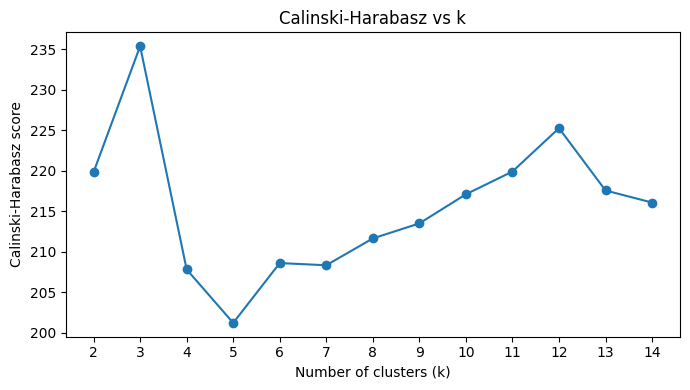

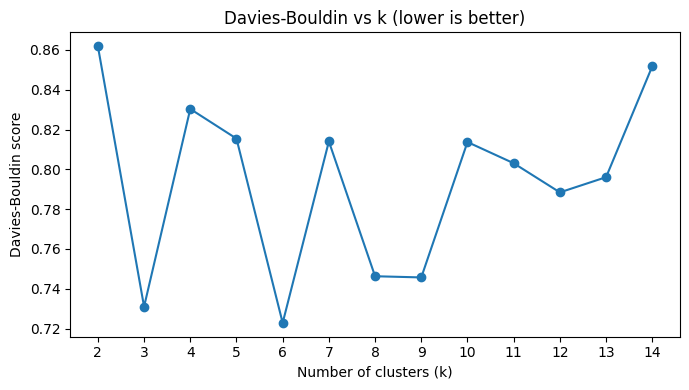

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from scipy.spatial.distance import squareform

# -----------------------------
# 0) Prepare data
# -----------------------------
feat_cols = ["gev_c", "gev_loc", "gev_scale"]

Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0].copy()

dfc = df.loc[Xdf.index].copy()

# log-transform scale
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

# -----------------------------
# 1) Global diagnostics over k
# -----------------------------
k_range = range(2, 15)

rows = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=20)
    labels = km.fit_predict(Xs)

    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(Xs, labels),
        "calinski_harabasz": calinski_harabasz_score(Xs, labels),
        "davies_bouldin": davies_bouldin_score(Xs, labels),
    })

diag_df = pd.DataFrame(rows)

# Best k according to individual criteria
best_k_sil = diag_df.loc[diag_df["silhouette"].idxmax(), "k"]
best_k_ch  = diag_df.loc[diag_df["calinski_harabasz"].idxmax(), "k"]
best_k_db  = diag_df.loc[diag_df["davies_bouldin"].idxmin(), "k"]

print("Best k by silhouette:", best_k_sil)
print("Best k by Calinski-Harabasz:", best_k_ch)
print("Best k by Davies-Bouldin:", best_k_db)

# -----------------------------
# 2) Composite rank score
#    (higher composite is better)
# -----------------------------
rank_sil = diag_df["silhouette"].rank(ascending=False, method="average")
rank_ch  = diag_df["calinski_harabasz"].rank(ascending=False, method="average")
rank_db  = diag_df["davies_bouldin"].rank(ascending=True, method="average")

diag_df["rank_total"] = rank_sil + rank_ch + rank_db
diag_df["rank_consensus"] = diag_df["rank_total"].rank(method="dense")
best_k = int(diag_df.loc[diag_df["rank_total"].idxmin(), "k"])

print("\nChosen k by combined ranking:", best_k)
print(diag_df.round(4))

# -----------------------------
# 3) Plot global diagnostics
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(diag_df["k"], diag_df["silhouette"], marker="o")
plt.xticks(diag_df["k"])
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette score")
plt.title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(diag_df["k"], diag_df["inertia"], marker="o")
plt.xticks(diag_df["k"])
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot vs k")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(diag_df["k"], diag_df["calinski_harabasz"], marker="o")
plt.xticks(diag_df["k"])
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz score")
plt.title("Calinski-Harabasz vs k")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(diag_df["k"], diag_df["davies_bouldin"], marker="o")
plt.xticks(diag_df["k"])
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin score")
plt.title("Davies-Bouldin vs k (lower is better)")
plt.tight_layout()
plt.show()



Ensemble clustering scores
Silhouette: 0.4792
Calinski-Harabasz: 203.5925
Davies-Bouldin: 0.839
ARI(single KMeans vs ensemble): 0.894

Stability summary against ensemble labels
          mean     std     min     max
method                                
agglo   0.3834  0.3679  0.1710  0.8082
gmm     0.7034  0.1173  0.5289  0.8526
kmeans  0.7341  0.2005  0.4570  0.8940


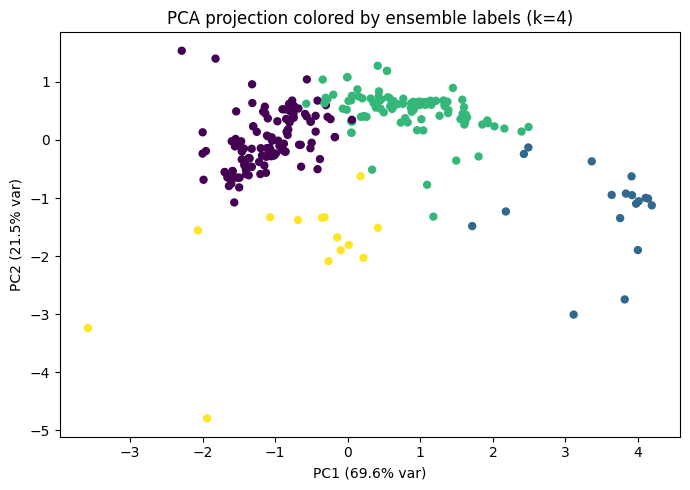

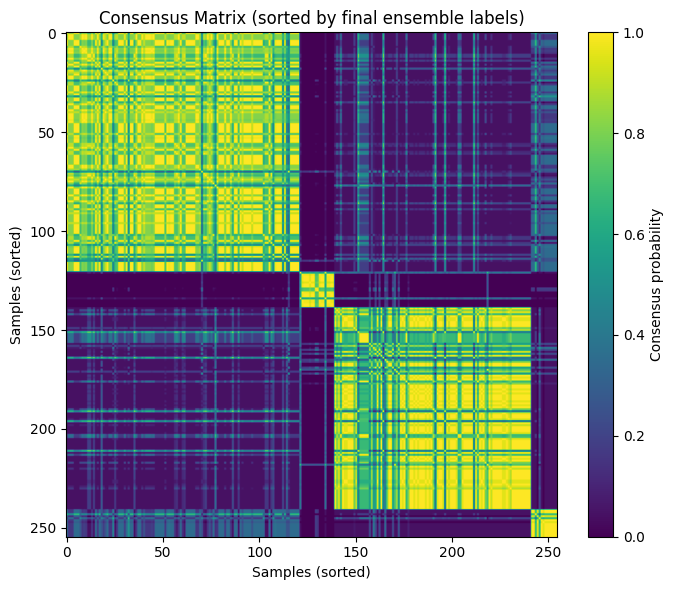

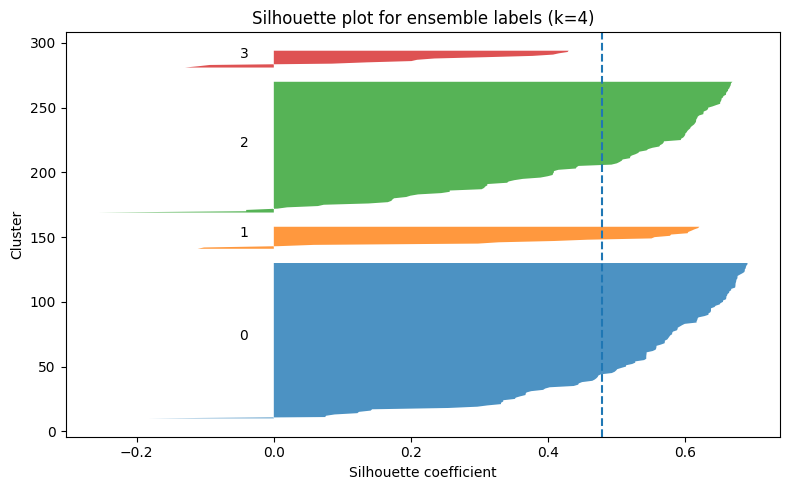


Cluster summary
                    n  gev_c_mean  gev_c_std  gev_loc_mean  gev_loc_std  \
cluster_ensemble                                                          
0                 121     -0.0071     0.1268        0.4553       0.1020   
1                  18      1.0204     0.2009        1.4367       0.4776   
2                 102      0.1772     0.1649        0.9037       0.1682   
3                  14      0.4907     0.1847        0.4999       0.1551   

                  log_gev_scale_mean  log_gev_scale_std  
cluster_ensemble                                         
0                            -1.6542             0.2414  
1                            -0.8695             0.3812  
2                            -1.0280             0.1829  
3                            -2.1170             0.6807  


In [53]:

# -----------------------------
# 4) Ensemble / consensus clustering
# -----------------------------
def coassociation_from_labels(labels):
    """Binary co-association matrix: 1 if same cluster, else 0."""
    labels = np.asarray(labels)
    return (labels[:, None] == labels[None, :]).astype(float)

def build_consensus_matrix(X, k, seeds=20):
    """
    Ensemble over multiple clustering algorithms / initializations.
    Returns average co-association matrix and all labelings.
    """
    n = X.shape[0]
    C = np.zeros((n, n), dtype=float)
    all_labels = []

    # KMeans ensemble
    for seed in range(seeds):
        km = KMeans(n_clusters=k, random_state=seed, n_init=20)
        lab = km.fit_predict(X)
        all_labels.append(("kmeans", seed, lab))
        C += coassociation_from_labels(lab)

    # Gaussian Mixture ensemble
    for seed in range(seeds):
        gm = GaussianMixture(n_components=k, covariance_type="full", random_state=seed)
        lab = gm.fit_predict(X)
        all_labels.append(("gmm", seed, lab))
        C += coassociation_from_labels(lab)

    # Agglomerative ensemble over a few linkage choices
    for linkage in ["ward", "complete", "average"]:
        ac = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        lab = ac.fit_predict(X)
        all_labels.append(("agglo", linkage, lab))
        C += coassociation_from_labels(lab)

    C /= len(all_labels)
    return C, all_labels
best_k=4
consensus_matrix, ensemble_labels = build_consensus_matrix(Xs, best_k, seeds=20)

# -----------------------------
# 5) Final labels from consensus matrix
# -----------------------------
# Turn similarity into distance
consensus_distance = 1.0 - consensus_matrix

# Agglomerative clustering on consensus distance
# For sklearn compatibility across versions:
try:
    consensus_model = AgglomerativeClustering(
        n_clusters=best_k,
        metric="precomputed",
        linkage="average"
    )
except TypeError:
    consensus_model = AgglomerativeClustering(
        n_clusters=best_k,
        affinity="precomputed",
        linkage="average"
    )

final_labels = consensus_model.fit_predict(consensus_distance)
dfc["cluster_ensemble"] = final_labels

# -----------------------------
# 6) Evaluate final ensemble labels
# -----------------------------
ens_sil = silhouette_score(Xs, final_labels)
ens_ch  = calinski_harabasz_score(Xs, final_labels)
ens_db  = davies_bouldin_score(Xs, final_labels)

print("\nEnsemble clustering scores")
print("Silhouette:", round(ens_sil, 4))
print("Calinski-Harabasz:", round(ens_ch, 4))
print("Davies-Bouldin:", round(ens_db, 4))

# Compare ensemble result to a single KMeans fit
km_single = KMeans(n_clusters=best_k, random_state=0, n_init=20)
labels_single = km_single.fit_predict(Xs)
ari_single_vs_ensemble = adjusted_rand_score(labels_single, final_labels)
print("ARI(single KMeans vs ensemble):", round(ari_single_vs_ensemble, 4))

# -----------------------------
# 7) Stability of ensemble members
# -----------------------------
aris_vs_final = []
for method_name, run_id, lab in ensemble_labels:
    aris_vs_final.append({
        "method": method_name,
        "run": run_id,
        "ARI_vs_final": adjusted_rand_score(lab, final_labels)
    })

stability_df = pd.DataFrame(aris_vs_final)
print("\nStability summary against ensemble labels")
print(stability_df.groupby("method")["ARI_vs_final"].agg(["mean", "std", "min", "max"]).round(4))

# -----------------------------
# 8) PCA visualization of final labels
# -----------------------------
pca = PCA(n_components=2, random_state=0)
Xp = pca.fit_transform(Xs)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(Xp[:, 0], Xp[:, 1], c=final_labels, s=25)
plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
plt.title(f"PCA projection colored by ensemble labels (k={best_k})")
plt.tight_layout()
plt.show()

# -----------------------------
# 9) Consensus matrix heatmap
# -----------------------------
order = np.argsort(final_labels)
C_sorted = consensus_matrix[order][:, order]

plt.figure(figsize=(7, 6))
plt.imshow(C_sorted, aspect="auto")
plt.colorbar(label="Consensus probability")
plt.title("Consensus Matrix (sorted by final ensemble labels)")
plt.xlabel("Samples (sorted)")
plt.ylabel("Samples (sorted)")
plt.tight_layout()
plt.show()

# -----------------------------
# 10) Silhouette plot for final labels
# -----------------------------
sample_sil = silhouette_samples(Xs, final_labels)

y_lower = 10
plt.figure(figsize=(8, 5))

for i in range(best_k):
    ith_vals = sample_sil[final_labels == i]
    ith_vals.sort()
    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_vals,
        alpha=0.8
    )

    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=ens_sil, linestyle="--")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.title(f"Silhouette plot for ensemble labels (k={best_k})")
plt.tight_layout()
plt.show()

# -----------------------------
# 11) Cluster summaries in original feature space
# -----------------------------
df_summary = Xdf.copy()
df_summary["cluster_ensemble"] = final_labels
df_summary["lat"] = dfc.lat
df_summary["lon"] = dfc.lon

cluster_summary = df_summary.groupby("cluster_ensemble").agg(
    n=("gev_c", "size"),
    gev_c_mean=("gev_c", "mean"),
    gev_c_std=("gev_c", "std"),
    gev_loc_mean=("gev_loc", "mean"),
    gev_loc_std=("gev_loc", "std"),
    log_gev_scale_mean=("gev_scale", "mean"),
    log_gev_scale_std=("gev_scale", "std"),
).round(4)

print("\nCluster summary")
print(cluster_summary)

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_95744/2548504260.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)


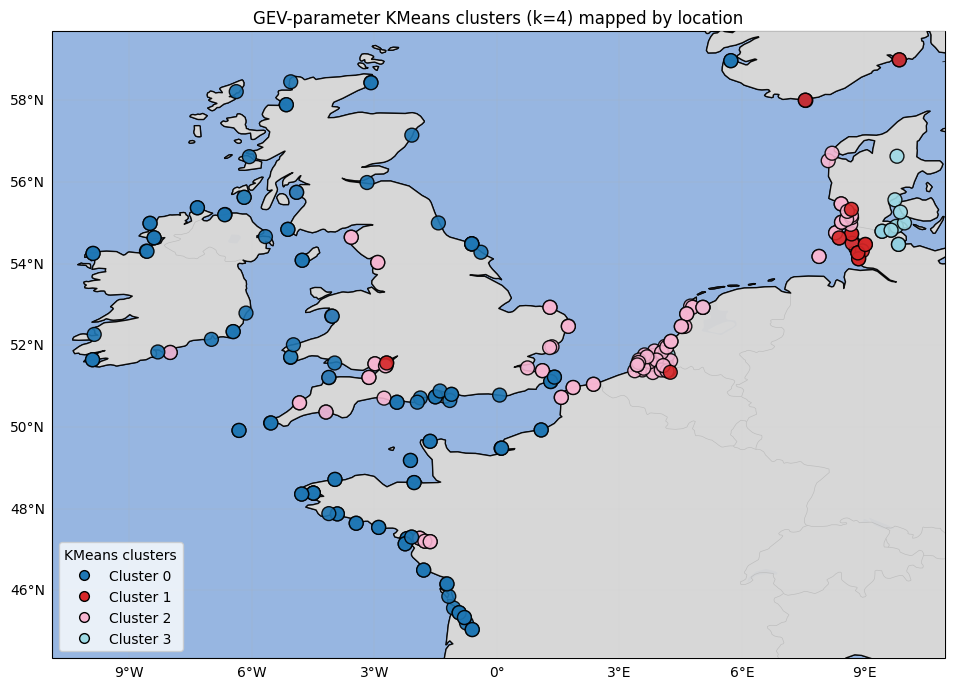

In [54]:
plotdf = df_summary[["lon", "lat", "cluster_ensemble"]].copy()

plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster_ensemble"] = pd.to_numeric(plotdf["cluster_ensemble"], errors="coerce")
plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()

# If best_k not in scope, infer from data
k = int(plotdf["cluster_ensemble"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

# Categorical colors for clusters
cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)

# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=7, markerfacecolor=cmap(i), markeredgecolor="k",
               label=f"Cluster {i}")
    for i in range(k)
]

# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"].values,
    plotdf["lat"].values,
    c=plotdf["cluster_ensemble"].values,
    cmap=cmap,
    norm=norm,
    s=100,
    zorder=40,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    edgecolors='black')
ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
ax.legend(handles=handles, title="KMeans clusters", loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


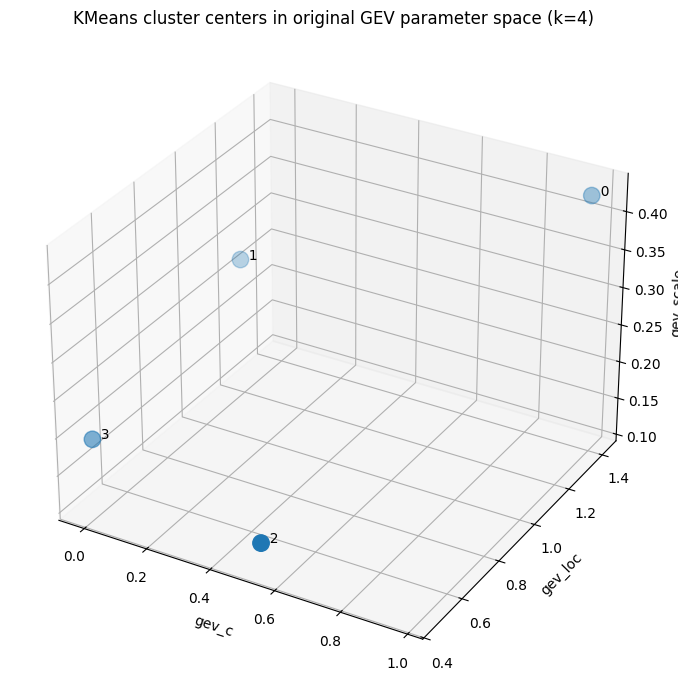

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Feature names (same order as used for fitting)
feat_cols = ["gev_c", "gev_loc", "gev_scale"]

# --------------------------------------------------
# 1. Get cluster centers in standardized space
# --------------------------------------------------
centers_std = km_single.cluster_centers_  # shape (k, 3)

# --------------------------------------------------
# 2. Invert standardization
# --------------------------------------------------
centers_unscaled = scaler.inverse_transform(centers_std)

# --------------------------------------------------
# 3. Undo log-transform on gev_scale
# --------------------------------------------------
centers_unscaled = centers_unscaled.copy()
centers_unscaled[:, 2] = np.exp(centers_unscaled[:, 2])

# --------------------------------------------------
# 4. Plot in ORIGINAL PARAMETER SPACE
# --------------------------------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    centers_unscaled[:, 0],
    centers_unscaled[:, 1],
    centers_unscaled[:, 2],
    s=140,
    marker="o",
    depthshade=True,
)

# Label each cluster center
for i in range(centers_unscaled.shape[0]):
    ax.text(
        centers_unscaled[i, 0],
        centers_unscaled[i, 1],
        centers_unscaled[i, 2],
        f"  {i}",
        fontsize=10,
    )

ax.set_xlabel("gev_c")
ax.set_ylabel("gev_loc")
ax.set_zlabel("gev_scale")
ax.set_title(f"KMeans cluster centers in original GEV parameter space (k={best_k})")

plt.tight_layout()
plt.show()


In [56]:
dfc.to_csv(f"/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/AAstation_GEV_4_msl.csv")

In [51]:
dfc.to_csv(f"/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/AAstation_GEV_6_msl.csv")